# Introducción a la Estadistica : Estadistica Descriptiva
---

### Cargando Librerías
---

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as ss
from scipy.stats import norm, variation, kurtosis, skew


### Utiizamos en dataset :  "acarreo" de una Mina Subterranea 
---

In [2]:
#Visualicemos de forma general la data que tenemos (5 primeras filas)
acarreo = pd.read_excel('BD_Extraccion.xlsx',sheet_name='datos', header=1)   # utilizamos la ubicacion fisica de archivo en la pc
acarreo.head(5)

,FECHA,TURNO,ZONA,TIPO_LABOR,NIVEL,CUERPO,VOLQUETES,PLAN,REAL
0,2020-01-01,T1,Alta,Tajos,3410,D,NaN,NaN,NaN
1,2020-01-01,T1,Alta,Tajos,3380,D,6.0,2500.0,1575.0
2,2020-01-01,T1,Alta,Tajos,3380,D,5.0,2500.0,2690.0
3,2020-01-01,T1,Baja,Tajos,3150,A,8.0,2600.0,2417.0
4,2020-01-01,T1,Baja,Tajos,3140,A,6.0,2000.0,985.0


### Información de las variables
---

In [3]:
acarreo.columns

Index([&#39;FECHA&#39;, &#39;TURNO&#39;, &#39;ZONA&#39;, &#39;TIPO_LABOR&#39;, &#39;NIVEL&#39;, &#39;CUERPO&#39;, &#39;VOLQUETES&#39;,
       &#39;PLAN&#39;, &#39;REAL&#39;],
      dtype=&#39;object&#39;)

In [4]:
acarreo.count()

FECHA         1149
TURNO         1149
ZONA          1149
TIPO_LABOR    1149
NIVEL         1149
CUERPO        1143
VOLQUETES      437
PLAN           559
REAL           990
dtype: int64

In [5]:
acarreo.info()

&lt;class &#39;pandas.core.frame.DataFrame&#39;&gt;
RangeIndex: 1149 entries, 0 to 1148
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   FECHA       1149 non-null   datetime64[ns]
 1   TURNO       1149 non-null   object        
 2   ZONA        1149 non-null   object        
 3   TIPO_LABOR  1149 non-null   object        
 4   NIVEL       1149 non-null   int64         
 5   CUERPO      1143 non-null   object        
 6   VOLQUETES   437 non-null    float64       
 7   PLAN        559 non-null    float64       
 8   REAL        990 non-null    float64       
dtypes: datetime64[ns](1), float64(3), int64(1), object(4)
memory usage: 80.9+ KB


### Cálculo de Indicadores de desempeño
---

In [6]:
#df1 = acarreo.groupby(['FECHA','TURNO'])[('PLAN_DIARIO','ACARREO_DIARIO','VOLQUETES')].sum().reset_index(['FECHA','TURNO'])
#acarreo['CUMPLIMIENTO'] = acarreo.apply(lambda row: row.REAL/row.PLAN, axis=1)
acarreo['PR'] = np.where((acarreo.PLAN>0) & (acarreo.PLAN>=acarreo.REAL),acarreo.REAL,acarreo.PLAN)      # PR  = Planeado Realizado 
acarreo['PNR'] = np.where((acarreo.PLAN>0) & (acarreo.PLAN>=acarreo.REAL),(acarreo.PLAN-acarreo.REAL),0) # PNR = Planeado No Realizado
acarreo['RNP'] = np.where((acarreo.PLAN>0) & (acarreo.REAL>acarreo.PLAN),(acarreo.REAL-acarreo.PLAN),0)  # RNP = Realizado No Planeado
acarreo['CUMP'] = (acarreo.PR + acarreo.RNP) / acarreo.PLAN # % Cumplimiento = (Planeado Realizado + Planeado No Realizado) / Planeado
acarreo['ADH'] = acarreo.PR / acarreo.PLAN                   # % Adherencia   =  Planeado Realizado / Planeado
acarreo.head(5)


,FECHA,TURNO,ZONA,TIPO_LABOR,NIVEL,CUERPO,VOLQUETES,PLAN,REAL,PR,PNR,RNP,CUMP,ADH
0,2020-01-01,T1,Alta,Tajos,3410,D,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN
1,2020-01-01,T1,Alta,Tajos,3380,D,6.0,2500.0,1575.0,1575.0,925.0,0.0,0.630000,0.630000
2,2020-01-01,T1,Alta,Tajos,3380,D,5.0,2500.0,2690.0,2500.0,0.0,190.0,1.076000,1.000000
3,2020-01-01,T1,Baja,Tajos,3150,A,8.0,2600.0,2417.0,2417.0,183.0,0.0,0.929615,0.929615
4,2020-01-01,T1,Baja,Tajos,3140,A,6.0,2000.0,985.0,985.0,1015.0,0.0,0.492500,0.492500


In [7]:
produccion = acarreo.groupby(['FECHA','TURNO','ZONA','CUERPO'])[('PLAN','REAL','VOLQUETES')].sum().reset_index(['FECHA','TURNO','ZONA','CUERPO'])
produccion = produccion[produccion['VOLQUETES'] >10]
produccion.head(3)

,FECHA,TURNO,ZONA,CUERPO,PLAN,REAL,VOLQUETES
0,2020-01-01,T1,Alta,D,5000.0,4265.0,11.0
1,2020-01-01,T1,Baja,A,4600.0,3402.0,14.0
13,2020-01-02,T2,Baja,A,4000.0,5597.0,13.0


In [8]:
prod = acarreo.groupby(['FECHA'])[('PLAN','REAL','VOLQUETES')].sum().reset_index(['FECHA'])
prod = prod[prod['VOLQUETES'] >0]
prod.head(5)

,FECHA,PLAN,REAL,VOLQUETES
0,2020-01-01,18000.0,15889.0,45.0
1,2020-01-02,18200.0,19411.0,47.0
2,2020-01-03,20700.0,18752.0,56.0
3,2020-01-04,20000.0,18503.0,44.0
4,2020-01-05,19900.0,20112.0,24.0


### Medidas de Resumen
---

In [9]:
prod.describe()

,PLAN,REAL,VOLQUETES
count,57.000000,57.000000,57.000000
mean,17526.315789,17763.508772,41.263158
std,2616.467515,2437.298820,13.264515
min,12000.000000,12271.000000,11.000000
25%,16000.000000,16218.000000,27.000000
50%,17800.000000,17913.000000,45.000000
75%,19400.000000,19411.000000,52.000000
max,21800.000000,22890.000000,62.000000


In [10]:
# Percentile values in summary, include 10% and 90%
deciles = prod.describe(percentiles=[.1, .2, .25, .3, .4, .5, .6, .7, .75, .8, .9, 1])
deciles

,PLAN,REAL,VOLQUETES
count,57.000000,57.000000,57.000000
mean,17526.315789,17763.508772,41.263158
std,2616.467515,2437.298820,13.264515
min,12000.000000,12271.000000,11.000000
10%,13800.000000,14708.000000,22.000000
20%,15180.000000,15447.000000,27.000000
25%,16000.000000,16218.000000,27.000000
30%,16340.000000,16509.400000,30.400000
40%,16940.000000,17170.600000,43.000000
50%,17800.000000,17913.000000,45.000000


In [11]:
prod.columns

Index([&#39;FECHA&#39;, &#39;PLAN&#39;, &#39;REAL&#39;, &#39;VOLQUETES&#39;], dtype=&#39;object&#39;)

In [12]:
from scipy.stats import mode
import statistics 

In [13]:
#Cálculo de la mediana y la moda
mediana_plan = np.median(prod.PLAN.sort_values())
moda_plan = mode(prod.PLAN.sort_values())

mediana_real = np.median(prod.REAL.sort_values())
moda_real = mode(prod.REAL.sort_values())

print("La mediana de la variable Plan es : ", mediana_plan)
print(f'La moda de las Plan es {moda_plan[0]} con una frecuencia de {moda_plan[1]}', "\n")
print("La mediana de la variable Real (acarreo) es : ", mediana_real)
print(f'La moda de las Real (Acarreo) es {moda_real[0]} con una frecuencia de {moda_real[1]}')


La mediana de la variable Plan es :  17800.0
La moda de las Plan es [16000.] con una frecuencia de [3] 

La mediana de la variable Real (acarreo) es :  17913.0
La moda de las Real (Acarreo) es [12271.] con una frecuencia de [1]


### Gráfico de producción Plan vs Real
---

&lt;function matplotlib.pyplot.show(close=None, block=None)&gt;

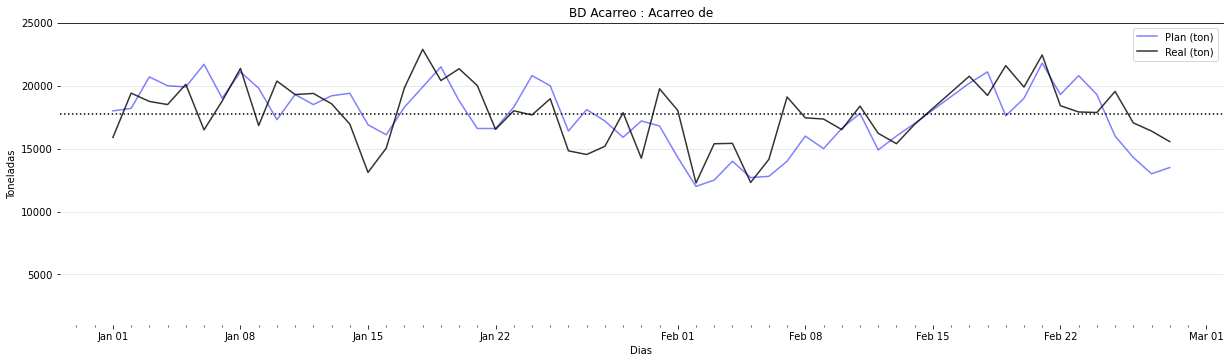

In [14]:
from matplotlib import dates as mdates
fig, ax = plt.subplots(figsize=(1500/72,400/72))
plt.plot(prod.FECHA,prod.PLAN, c='b', zorder=0, alpha=.5 ,label='Plan (ton)')
plt.plot(prod.FECHA,prod.REAL, c='k', zorder=1, alpha=.8 ,label='Real (ton)')
#desempeno.plot(x='FECHA',y='CUMP', kind='bar')
ax.legend()
ax.xaxis.set_minor_locator(mdates.DayLocator())
ax.grid(which='major', axis='y', c='k', alpha=.1, zorder=-2)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_title('BD Acarreo : Acarreo de')
plt.axhline(17763, color='k', xmax=1 ,ls="dotted")
plt.ylim(1000, 25000)
ax.set_ylabel('Toneladas')
ax.set_xlabel('Dias')

ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
plt.show

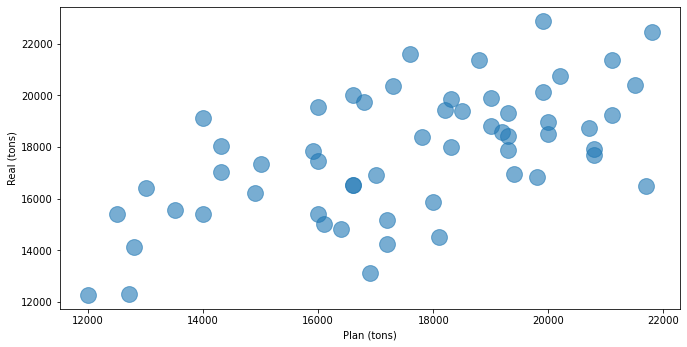

In [15]:
#Diagramas de dispersion
plt.subplots(figsize=(800/72,400/72))
plt.scatter(prod['PLAN'], prod['REAL'], s=250,alpha=0.6)
plt.xlabel('Plan (tons)')
plt.ylabel('Real (tons)')
plt.show()

Text(-9.074999999999996, 0.5, &#39;Real (tons)&#39;)

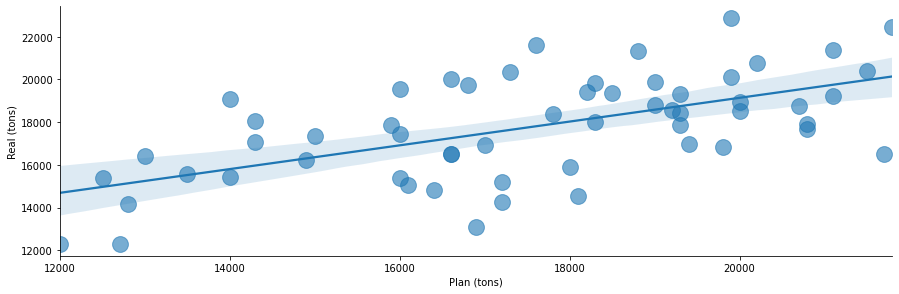

In [16]:
from seaborn import lmplot
lmplot('PLAN', 'REAL', data=prod, scatter_kws={"s": 250, "alpha": 0.6}, height=4, aspect=3.1)
plt.xlabel('Plan (tons)')
plt.ylabel('Real (tons)')


### Analisis de Desempeño
---

In [17]:
desempeno = acarreo.groupby(['FECHA','TURNO','ZONA','CUERPO'])[('CUMP','ADH','VOLQUETES')].mean().reset_index(['FECHA','TURNO','ZONA','CUERPO'])
desempeno = desempeno[desempeno['VOLQUETES'] >0]
desempeno.head(3)

,FECHA,TURNO,ZONA,CUERPO,CUMP,ADH,VOLQUETES
0,2020-01-01,T1,Alta,D,0.853000,0.815000,5.5
1,2020-01-01,T1,Baja,A,0.711058,0.711058,7.0
3,2020-01-01,T2,Alta,D,0.735800,0.693400,4.0


In [18]:
desempeno = acarreo.groupby(['FECHA'])[('CUMP','ADH','VOLQUETES')].mean().reset_index(['FECHA'])
desempeno = desempeno[desempeno['VOLQUETES'] >0]
desempeno.head(4)

,FECHA,CUMP,ADH,VOLQUETES
0,2020-01-01,0.979652,0.804864,5.625000
1,2020-01-02,0.937221,0.891789,5.222222
2,2020-01-03,0.895818,0.805751,5.090909
3,2020-01-04,0.758572,0.758572,4.400000


In [109]:
desempeno.count()

FECHA        57
CUMP         57
ADH          57
VOLQUETES    57
dtype: int64

In [19]:
desempeno.describe()

,CUMP,ADH,VOLQUETES
count,57.000000,57.000000,57.000000
mean,0.904597,0.789264,5.428418
std,0.150288,0.083793,0.493238
min,0.555936,0.549186,4.300000
25%,0.786856,0.738114,5.125000
50%,0.926221,0.804082,5.400000
75%,1.007512,0.857099,5.625000
max,1.308509,0.928765,6.750000


### Gráfica de Desempeño : Cumplimiento y Adherencia
---

&lt;function matplotlib.pyplot.show(close=None, block=None)&gt;

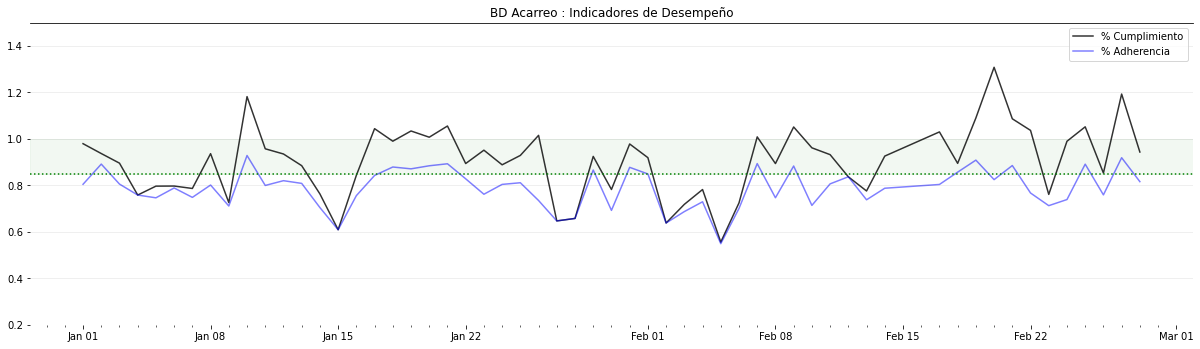

In [20]:
from matplotlib import dates as mdates
fig, ax = plt.subplots(figsize=(1500/72,400/72))
plt.plot(desempeno.FECHA,desempeno.CUMP, c='k', zorder=1, alpha=.8 ,label='% Cumplimiento')
plt.plot(desempeno.FECHA,desempeno.ADH, c='b', zorder=1, alpha=.5 ,label='% Adherencia')
#desempeno.plot(x='FECHA',y='CUMP', kind='bar')
ax.legend()
ax.xaxis.set_minor_locator(mdates.DayLocator())
ax.grid(which='major', axis='y', c='k', alpha=.08, zorder=-2)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_title('BD Acarreo : Indicadores de Desempeño')
plt.ylim(0.2, 1.5)
plt.axhline(0.85, color='g', xmax=1 ,ls="dotted")
plt.axhspan(0.85,1, alpha=0.05, color='g', zorder = 0)

ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
plt.show

### Grafico de KPIs
---

In [21]:
acarreo.head(5)

,FECHA,TURNO,ZONA,TIPO_LABOR,NIVEL,CUERPO,VOLQUETES,PLAN,REAL,PR,PNR,RNP,CUMP,ADH
0,2020-01-01,T1,Alta,Tajos,3410,D,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN
1,2020-01-01,T1,Alta,Tajos,3380,D,6.0,2500.0,1575.0,1575.0,925.0,0.0,0.630000,0.630000
2,2020-01-01,T1,Alta,Tajos,3380,D,5.0,2500.0,2690.0,2500.0,0.0,190.0,1.076000,1.000000
3,2020-01-01,T1,Baja,Tajos,3150,A,8.0,2600.0,2417.0,2417.0,183.0,0.0,0.929615,0.929615
4,2020-01-01,T1,Baja,Tajos,3140,A,6.0,2000.0,985.0,985.0,1015.0,0.0,0.492500,0.492500


In [22]:
kpis = acarreo.groupby(['FECHA',])[('PR','PNR','RNP','VOLQUETES')].sum().reset_index(['FECHA'])
kpis = kpis[kpis['VOLQUETES'] >0]
kpis.head(3)

,FECHA,PR,PNR,RNP,VOLQUETES
0,2020-01-01,14344.0,3656.0,897.0,45.0
1,2020-01-02,15958.0,2242.0,800.0,47.0
2,2020-01-03,17234.0,3466.0,1921.0,56.0


&lt;function matplotlib.pyplot.show(close=None, block=None)&gt;

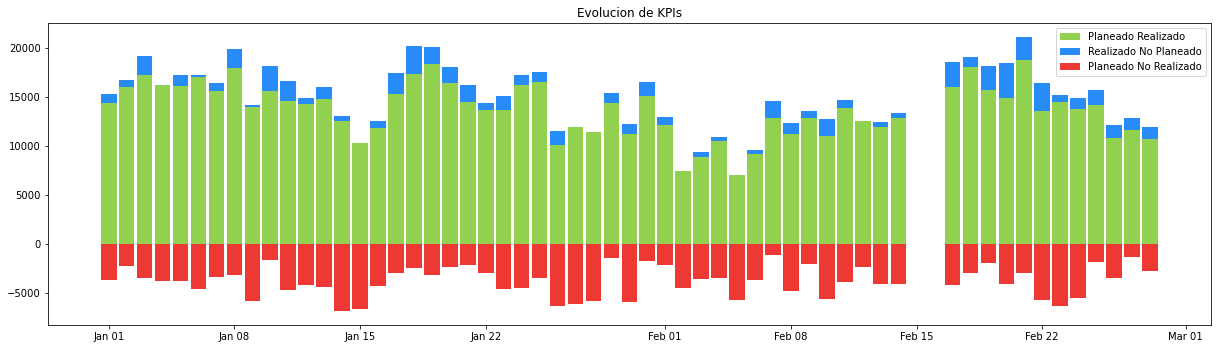

In [23]:
from matplotlib import dates as mdates
fig, ax = plt.subplots(figsize=(1500/72,400/72))

width = .87  
ax.bar(kpis.FECHA,  kpis.PR, width,label='Planeado Realizado',color='#92D050')
ax.bar(kpis.FECHA, kpis.RNP, width,  bottom= kpis.PR,label='Realizado No Planeado', color='#278CF7')
ax.bar(kpis.FECHA, (kpis.PNR)*-1, width,label='Planeado No Realizado', color='#ED3833') 

ax.set_title('Evolucion de KPIs')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
plt.show

In [24]:
prod = acarreo.groupby(['FECHA'])[('PLAN','REAL','VOLQUETES')].sum().reset_index(['FECHA'])
#prod = prod[prod['VOLQUETES'] >0]
prod.head(4)

,FECHA,PLAN,REAL,VOLQUETES
0,2020-01-01,18000.0,15889.0,45.0
1,2020-01-02,18200.0,19411.0,47.0
2,2020-01-03,20700.0,18752.0,56.0
3,2020-01-04,20000.0,18503.0,44.0


## Analisis : Producción por Turno
---

In [25]:
prod_turno = acarreo.groupby(['FECHA','TURNO'])[('PLAN','REAL','VOLQUETES')].sum().reset_index(['FECHA','TURNO'])
prod_turno = prod_turno[prod_turno['VOLQUETES'] >0]
prod_turno.head(4)

,FECHA,TURNO,PLAN,REAL,VOLQUETES
0,2020-01-01,T1,9600.0,7927.0,25.0
1,2020-01-01,T2,8400.0,7962.0,20.0
2,2020-01-02,T1,8400.0,8543.0,18.0
3,2020-01-02,T2,9800.0,10868.0,29.0


### Medidas de Posición
---
* Medidas de Tendencia Central : media, mediana, moda
* Medidas de Tendencia No Central : cuartiles, deciles, percentiles


In [26]:
prod_turno.describe()

,PLAN,REAL,VOLQUETES
count,97.000000,97.000000,97.000000
mean,8837.113402,8942.907216,24.247423
std,1447.650366,1510.379858,4.679367
min,4500.000000,5247.000000,5.000000
25%,8000.000000,7927.000000,22.000000
50%,9000.000000,8866.000000,25.000000
75%,10000.000000,10205.000000,27.000000
max,12200.000000,11997.000000,32.000000


### Quartiles y Deciles

---
#### Qk = Dividen al conjunto de datos en cuatro partes iguales
#### Dk = Los deciles son nueve valores (Dk; k = 1, 2, ..., 9) que dividen al conjunto de datos en diez partes iguales

In [27]:
# Percentile values in summary, include 10% and 90%
deciles = prod_turno.describe(percentiles=[.1, .2, .25, .3, .4, .5, .6, .7, .75, .8, .9, 1])
deciles

,PLAN,REAL,VOLQUETES
count,97.000000,97.000000,97.000000
mean,8837.113402,8942.907216,24.247423
std,1447.650366,1510.379858,4.679367
min,4500.000000,5247.000000,5.000000
10%,6920.000000,6820.200000,19.600000
20%,7540.000000,7616.000000,21.000000
25%,8000.000000,7927.000000,22.000000
30%,8080.000000,8153.600000,23.000000
40%,8500.000000,8526.800000,24.000000
50%,9000.000000,8866.000000,25.000000


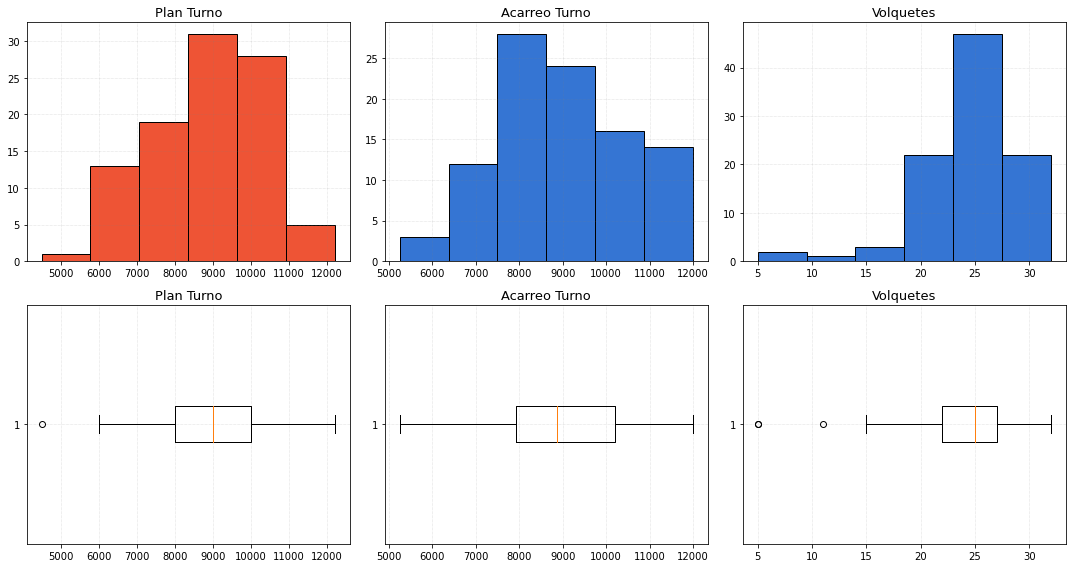

In [28]:
# Histogramas
#fig, (ax0, ax1, ax2) = plt.subplots(1, 3, figsize=(10,4), sharey=True, sharex=True)
fig, ((ax0, ax1, ax2) , (ax3, ax4, ax5)) = plt.subplots(2, 3, figsize=(15,8))
#fig, (ax0, ax1) = plt.subplots(nrows=1, ncols=2)


ax0.hist(x = prod_turno['PLAN'], bins = 6, histtype='bar', edgecolor='#000000', color='#EE5435')
ax0.set_title('Plan Turno', fontsize=13)
ax0.grid(linestyle=':', linewidth='0.5', color='grey', alpha=0.5)

ax1.hist(x = prod_turno['REAL'], bins = 6, histtype='bar', edgecolor='#000000',color='#3575D3')
ax1.grid(linestyle=':', linewidth='0.5', color='grey', alpha=0.5)
ax1.set_title('Acarreo Turno',fontsize=13)

ax2.hist(x = prod_turno['VOLQUETES'], bins = 6, histtype='bar', edgecolor='#000000',color='#3575D3')
ax2.grid(linestyle=':', linewidth='0.5', color='grey', alpha=0.5)
ax2.set_title('Volquetes',fontsize=13)

ax3.boxplot(x = prod_turno["PLAN"], vert=False)
ax3.grid(linestyle=':', linewidth='0.5', color='grey', alpha=0.5)
ax3.set_title('Plan Turno',fontsize=13)

ax4.boxplot(x = prod_turno["REAL"], vert=False)
ax4.grid(linestyle=':', linewidth='0.5', color='grey', alpha=0.5)
ax4.set_title('Acarreo Turno',fontsize=13)

ax5.boxplot(x = prod_turno["VOLQUETES"], vert=False)
ax5.grid(linestyle=':', linewidth='0.5', color='grey', alpha=0.5)
ax5.set_title('Volquetes',fontsize=13)

# If you don't do tight_layout() you'll have weird overlaps
fig.tight_layout()

### Medidas de Dispersión : Rango (R) y Rango Intercuartilico (RI)

---
* Rango (R) : *Es una medida de variabilidad que se obtiene de la diferencia entre el máximo y mínimo valor de la variable.*

* Rango Intercuartilico (RI) : *Se define como la diferencia entre los cuartiles tres (Q3) y uno (Q1); tambien podemos decir que es el rango en el que se encuentra el 50% central de los datos.*


In [29]:
range_Plan = prod_turno['PLAN'].max() - prod_turno['PLAN'].min()
print(" Rango (Plan Turno) :", range_Plan)

range_Acarreo = prod_turno['REAL'].max() - prod_turno['REAL'].min()
print(" Rango (Acarreo Turno) :",range_Acarreo)

range_Volquete = prod_turno['VOLQUETES'].max() - prod_turno['VOLQUETES'].min()
print(" Rango (Volquetes Turno) :",range_Volquete)

 Rango (Plan Turno) : 7700.0
 Rango (Acarreo Turno) : 6750.0
 Rango (Volquetes Turno) : 27.0


In [30]:
IQR_Plan = ss.iqr(prod_turno['PLAN'])
print(" Rango Intercuartílico (Plan Turno) :", IQR_Plan)

IQR_Acarreo = ss.iqr(prod_turno['REAL'])
print(" Rango Intercuartílico (Acarreo Turno) :",IQR_Acarreo)

IQR_Volquetes = ss.iqr(prod_turno['VOLQUETES'])
print(" Rango Intercuartílico (Volquetes) :",IQR_Volquetes)


 Rango Intercuartílico (Plan Turno) : 2000.0
 Rango Intercuartílico (Acarreo Turno) : 2278.0
 Rango Intercuartílico (Volquetes) : 5.0


### Varianza y Desviacion Estandar 
---
* Varianza (var) : * Mide la variabilidad del conjunto de datos con respecto a la media.*

* Desviacion Estandar (std): *La desviación estándar mide la desviación media o promedio de cada dato con respecto a la media y se define como la raíz cuadrada de la varianza.*

In [31]:

std_real = prod_turno['REAL'].std(ddof=1)
print ("Desviacion Estandar (Acarreo por Turno) :", std_real.round(1))

var_real = prod_turno['REAL'].var(ddof=1)
print ("Varianza (Acarreo por Turno) :", var_real.round(1))

std_volq = prod_turno['VOLQUETES'].std(ddof=1)
print ("Desviacion Estandar (Producción por Turno):", std_volq.round(1))

var_volq= prod_turno['VOLQUETES'].var(ddof=1)
print ("Varianza (Volquetes por Turno) :", var_volq.round(1))

Desviacion Estandar (Acarreo por Turno) : 1510.4
Varianza (Acarreo por Turno) : 2281247.3
Desviacion Estandar (Producción por Turno): 4.7
Varianza (Volquetes por Turno) : 21.9


### Medidas de Asimetría

---
#### Estas medidas brindan información sobre la dirección horizontal que toma la distribución de los datos con respecto a su centro.

* Ak < 0 tiene Asimetria negativa, Indica que existe presencia de la minoría de datos en la parte izquierda de la media.

* Ak = 0 Distribucion simetrica, la distribución será simétrica.

* Ak > 0 Distribucion con Asimetria Positiva, Indica que existe presencia de la minoría de datos en la parte derecha de la media.

In [32]:
#La función dataframe.skew() de Pandas devuelve la asimetria
prod_turno.skew(axis = 0, skipna = True)

PLAN        -0.309214
REAL        -0.029751
VOLQUETES   -1.634478
dtype: float64

Los resultados indican que todos tienen asimetria negativa, indica que la minoria de datos estan en la parte izquierda, aunque los datos de producción por turno (REAL), esta cerca de ser Simetrica.

### Medidas de Curtosis
---
#### Estas medidas brindan información sobre la deformación vertical de una distribución de frecuencias en comparación con la curva normal
* Ku > 0.263 : Distribución Leptocúrtica, forma mas punteada, los datos estan muy concentrados a la media.

* Ku = 0.263 : Distribución Mesocúrtica, forma normal,  tiene un comportamiento normal exige que la curtosis sea igual a la media.

* Ku < 0.263 : Distribución Platicúrtica, forma aplanada , los datos estan muy dispersos de la media. 

In [33]:
#La función dataframe.kurt() de Pandas devuelve una curtosis
prod_turno.kurt(axis=0, skipna = True)

PLAN        -0.063672
REAL        -0.558170
VOLQUETES    4.764062
dtype: float64

Los resultados indican que los datos del Plan del turno estan mas dispersos de la media, teniendo una forma mas plana, a diferencia de los volquetes que sus valores se concnetran en la media, haciendola que tenga una forma mas punteada. 

### Covarianza y Correlación de Pearson

---

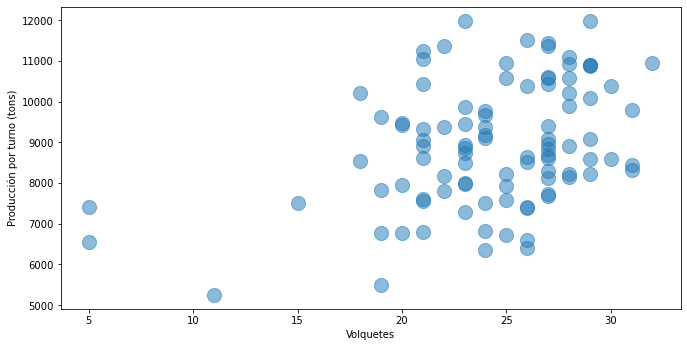

In [34]:
#Diagramas de dispersion
plt.subplots(figsize=(800/72,400/72))
plt.scatter(prod_turno['VOLQUETES'], prod_turno['REAL'], s=200,alpha=0.5 )
plt.xlabel('Volquetes')
plt.ylabel('Producción por turno (tons)')
plt.show()

Hemos generado un diagrama de dispersión para ver la relación entre los datos de Volquetes y producción por turno, pero vamos a profundizar mas en la data para ver a nivel de zonas donde se extrae el mineral, para encontrar alguna relación que nos de mas detalles.

### Covarianza

---
* Si Cov(x,y) > 0, hay dependencia directa (positiva), es decir a grandes valores de X corresponden grandes valores de Y.

* Si Cov(x,y) = 0, Una covarianza (0) se interpreta como la no existencia de una relación lineal entre las dos variables estudiadas.

* Si Cov(x,y) < 0, hay dependencia inversa o negativa es decir, a grandes valores de X corresponden pequeños valores de Y


In [35]:
#Pandas dataframe.cov() se utiliza para calcular la covarianza por pares de las columnas.

cov_mat = prod_turno.cov()
cov_mat

,PLAN,REAL,VOLQUETES
PLAN,2.095692e+06,1.055669e+06,2478.221649
REAL,1.055669e+06,2.281247e+06,2731.200279
VOLQUETES,2.478222e+03,2.731200e+03,21.896478


Interpretación : Podemos verificar que,

- Entre las variables "Plan" y "Producción por turno" existe una "depdenencia directa", cov(x,y)= 1,05 > 0, es deciar ambas crecen en la misma dirección.

- Entre las variables "Plan" y "Volquetes" existe una "dependencia directa", cov(x,y)= 2,478 > 0.

- Entre Las variables "Producción por turno" y " Volquetes" existe una "dependencia directa", cov(x,y)= 2,771 > 0.

### Correlacion de Pearson (R)

---
* R ≅ −1: La relación entre las variables es perfecta e inversa.

* R ≅ 0: No existe relación entre las variables

* R ≅ 1: La relación entre las variables es perfecta y directa.


In [36]:
# Pandas dataframe.corr() se utiliza para encontrar la correlación por pares de todas las columnas del dataframe
corr_mat = prod_turno.corr()
corr_mat

,PLAN,REAL,VOLQUETES
PLAN,1.000000,0.482812,0.365838
REAL,0.482812,1.000000,0.386438
VOLQUETES,0.365838,0.386438,1.000000


Interpretacion: Podemos verificar que,

(R = 0.48) Entre las variables "Plan" y "Producción por turno" existe una "relación  positiva", es decir tanto Plan y producción se correlacion directamente.

(R = 0.36) Entre las variables "Plan" y "Volquetes" existe una "relación  positiva".

(R = 0.38) Entre Las variables "Producción por turno" y " Volquetes" existe una relación  positiva.

In [37]:
prod_turno_zona = acarreo.groupby(['FECHA','TURNO','ZONA'])[('PLAN','REAL','VOLQUETES')].sum().reset_index(['FECHA','TURNO','ZONA'])
prod_turno_zona = prod_turno_zona[prod_turno_zona['VOLQUETES'] >0]
prod_turno_zona.head(4)

,FECHA,TURNO,ZONA,PLAN,REAL,VOLQUETES
0,2020-01-01,T1,Alta,5000.0,4265.0,11.0
1,2020-01-01,T1,Baja,4600.0,3662.0,14.0
2,2020-01-01,T2,Alta,5000.0,4212.0,8.0
3,2020-01-01,T2,Baja,3400.0,3750.0,12.0


### Otros Graficos de Dispersión
---

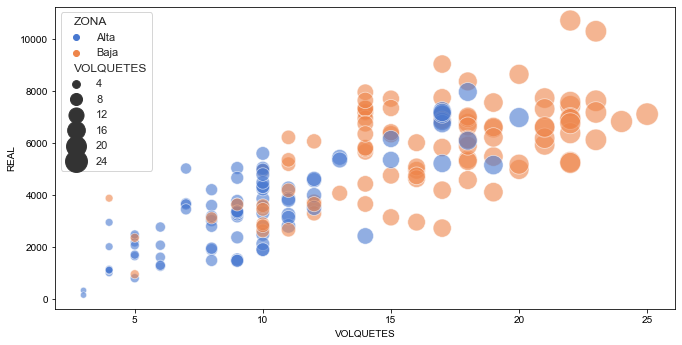

In [38]:
plt.subplots(figsize=(800/72,400/72))
sns.set_theme(style="white")
sns.scatterplot(x='VOLQUETES',y='REAL', hue="ZONA", size="VOLQUETES",sizes=(40, 500), data=prod_turno_zona, s=200, alpha=0.6, palette="muted")
#plt.xlabel('Volquetes')
#plt.ylabel('Producción por turno (tons)')
plt.show()

Hemos realizado un gráfico de dispersion identificando las ZONAS de origen del mineral acarreado y dimensionando cada punto de acuerdo a la cantidad de volquetes asigandos.

EL gráfico muestra que existe una mayor concentración de actividades en la zona baja de la mina y a la vez es donde se concentra una mayor cantidad de volquetes asignados por turno.

In [39]:
prod_turno_zona.describe()

,PLAN,REAL,VOLQUETES
count,180.000000,180.000000,180.000000
mean,4701.111111,4686.477778,13.066667
std,2292.591637,2117.035828,5.423516
min,0.000000,166.000000,3.000000
25%,3000.000000,3136.750000,9.000000
50%,5000.000000,4650.500000,12.000000
75%,6500.000000,6455.500000,17.000000
max,9000.000000,10706.000000,25.000000


In [40]:
prod_turno_cuerpo = acarreo.groupby(['FECHA','TURNO','ZONA','CUERPO'])[('PLAN','REAL','VOLQUETES')].sum().reset_index(['FECHA','TURNO','ZONA','CUERPO'])
prod_turno_cuerpo = prod_turno_cuerpo[prod_turno_cuerpo['VOLQUETES'] >0]
prod_turno_cuerpo.head(4)

,FECHA,TURNO,ZONA,CUERPO,PLAN,REAL,VOLQUETES
0,2020-01-01,T1,Alta,D,5000.0,4265.0,11.0
1,2020-01-01,T1,Baja,A,4600.0,3402.0,14.0
3,2020-01-01,T2,Alta,D,5000.0,3679.0,8.0
5,2020-01-01,T2,Baja,A,3000.0,2345.0,8.0


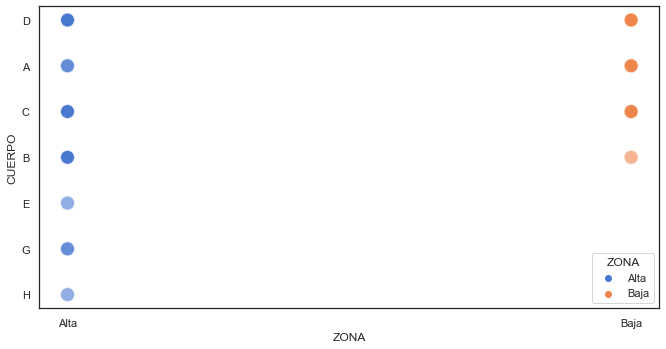

In [41]:
plt.subplots(figsize=(800/72,400/72))
sns.set_theme(style="white")
sns.scatterplot(x='ZONA',y='CUERPO', hue="ZONA", data=prod_turno_cuerpo, s=200, alpha=0.6, palette="muted")
#plt.xlabel('Volquetes')
#plt.ylabel('Producción por turno (tons)')
plt.show()

&lt;seaborn.axisgrid.FacetGrid at 0x7fd336bb7d90&gt;

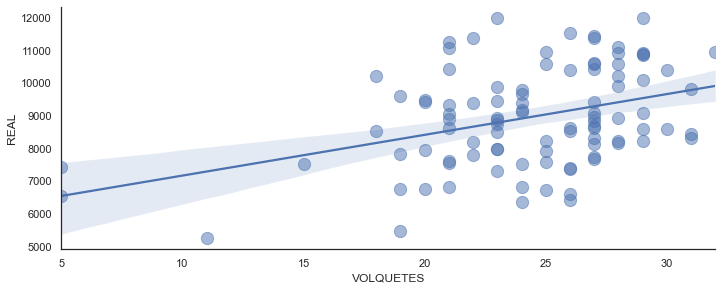

In [42]:
#La gráfica además de los datos incluye la regresión lineal y el intervalo de confianza
from seaborn import lmplot
lmplot('VOLQUETES', 'REAL', data=prod_turno, scatter_kws={"s": 150, "alpha": 0.5}, height=4, aspect=2.5)

&lt;seaborn.axisgrid.FacetGrid at 0x7fd336bc08d0&gt;

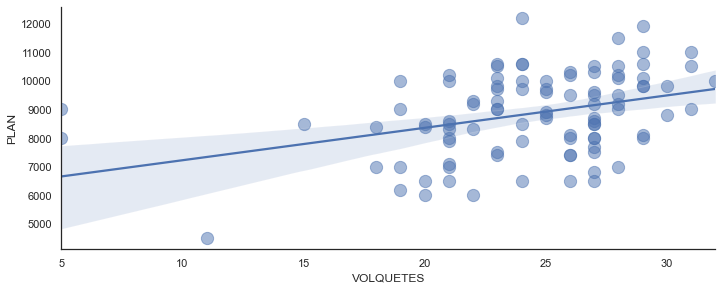

In [43]:
#La gráfica además de los datos incluye la regresión lineal y el intervalo de confianza
from seaborn import lmplot
lmplot('VOLQUETES', 'PLAN', data=prod_turno, scatter_kws={"s": 150, "alpha": 0.5}, height=4, aspect=2.5)

&lt;seaborn.axisgrid.FacetGrid at 0x7fd332336d90&gt;

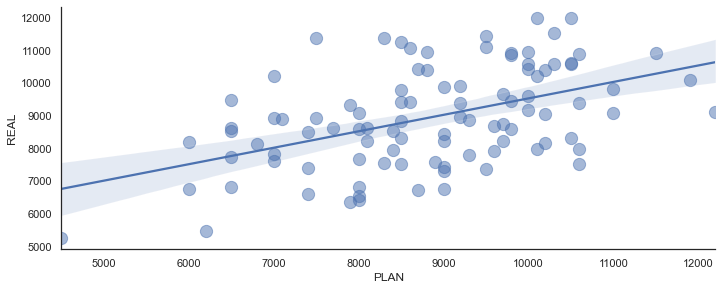

In [44]:
#La gráfica además de los datos incluye la regresión lineal y el intervalo de confianza
from seaborn import lmplot
lmplot('PLAN', 'REAL', data=prod_turno, scatter_kws={"s": 150, "alpha": 0.5}, height=4, aspect=2.5)